# $\lambda$-return and TD($\lambda$)

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
class RandomWalk:
    def __init__(self, num_states=19):
        self.num_states = num_states
        self.start_state = self.num_states // 2
        self.current_state = None

    def reset(self):
        self.current_state = self.start_state
        return {'state':self.current_state}

    def is_terminal(self):
        return self.current_state == 0 or self.current_state == self.num_states - 1

    def step(self, action):
        if self.is_terminal():
            return {'state':self.current_state, 'reward':0.0}

        if action == 0:
            self.current_state -= 1
        else:
            self.current_state += 1

        if self.current_state == 0:
            reward = -1.0
        elif self.current_state == self.num_states - 1:
            reward = 1.0
        else:
            reward = 0.0
        return {'state':self.current_state, 'reward':reward}


In [4]:
feature_vectors = np.eye(21, 21, 0)

In [5]:
def rms(w:np.ndarray, v_star:np.ndarray):
    v = w.T@feature_vectors
    return np.sqrt(np.mean((v[1:-1] - v_star[1:-1]) ** 2))

# True Online TD($\lambda$)

In [22]:
def true_online_lambda(
    w:np.ndarray,
    env:RandomWalk,
    episodes:int,
    lambda_:float=0.0,
    gamma:float=1.0,
    alpha:float=0.1
):
    for episode in range(episodes):
        state = env.reset()['state']
        x = feature_vectors[state]
        z = np.zeros_like(w)
        old_v = 0
        while not env.is_terminal():
            action = np.random.choice(2)
            feedback = env.step(action)
            new_state = feedback['state']
            reward = feedback['reward']

            x_prime = feature_vectors[new_state]

            v = w.T@x
            v_prime = w.T@x_prime
            delta = reward + gamma * v_prime - v
            z = gamma * lambda_ * z + (1 - alpha * gamma * lambda_ * z.T @ x) * x

            w = w + alpha * (delta + v - old_v) * z + alpha * (old_v - v) * x
            old_v = v_prime
            x = x_prime
    return w


In [23]:
env = RandomWalk(21)
w = np.zeros(env.num_states)
v_star = np.linspace(-1, 1, env.num_states)
v_star[0] = 0.0
v_star[-1] = 0.0

print("The loss is", rms(w, v_star))

The loss is 0.5477225575051662


In [50]:
alphas = np.linspace(0.01, 1.0, 20)
lambdas = [0.0, 0.4, 0.8, 0.9, 0.95, 0.975, 0.99, 1.0]

runs = 50

result = {}

for lambda_ in lambdas:
    print(lambda_)
    alpha_results = []
    for alpha in alphas:
        loss = 0
        for run in range(runs):
            w = np.zeros(env.num_states)
            w = true_online_lambda(
                w=w,
                env=env,
                episodes=10,
                lambda_=lambda_,
                gamma=0.99,
                alpha=alpha
            )

            loss += rms(w, v_star)
        alpha_results.append((alpha, loss / runs))
    alpha_results = np.array(alpha_results, dtype=np.float32)
    result[float(lambda_)] = alpha_results

0.0
0.4
0.8
0.9
0.95
0.975
0.99
1.0


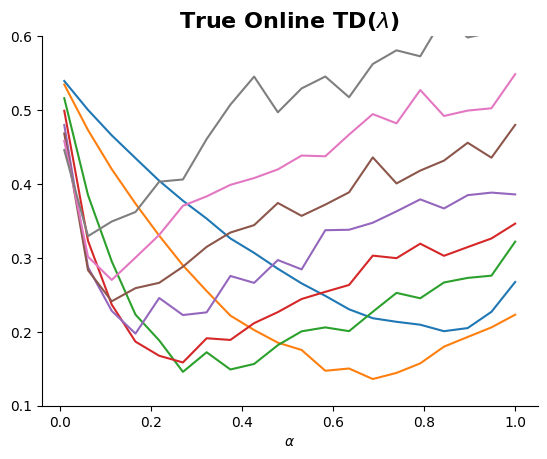

In [51]:
plt.figure()
ax = plt.subplot(111)

for lambda_, value in result.items():
    ax.plot(value[:, 0], value[:, 1])

ax.set_ylim([0.1, 0.6])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel(r"$\alpha$");
ax.set_title(r"True Online TD($\lambda$)", fontdict={'fontsize':16, 'fontweight':1000});

In [38]:
result[:, 1]

array([0.        , 0.05263158, 0.10526316, 0.15789473, 0.21052632,
       0.2631579 , 0.31578946, 0.36842105, 0.42105263, 0.47368422,
       0.5263158 , 0.57894737, 0.6315789 , 0.68421054, 0.7368421 ,
       0.7894737 , 0.84210527, 0.8947368 , 0.94736844, 1.        ],
      dtype=float32)

In [39]:
result

array([[0.01      , 0.        , 0.4733937 ],
       [0.06210526, 0.05263158, 0.22299173],
       [0.11421052, 0.10526316, 0.12846115],
       [0.1663158 , 0.15789473, 0.04594374],
       [0.21842106, 0.21052632, 0.07877786],
       [0.27052632, 0.2631579 , 0.07258891],
       [0.32263157, 0.31578946, 0.07328673],
       [0.37473685, 0.36842105, 0.123654  ],
       [0.4268421 , 0.42105263, 0.12771897],
       [0.47894737, 0.47368422, 0.19734009],
       [0.53105265, 0.5263158 , 0.1732549 ],
       [0.5831579 , 0.57894737, 0.15217717],
       [0.63526314, 0.6315789 , 0.08906744],
       [0.6873684 , 0.68421054, 0.11561517],
       [0.7394737 , 0.7368421 , 0.20466793],
       [0.79157895, 0.7894737 , 0.36427104],
       [0.8436842 , 0.84210527, 0.24494705],
       [0.89578944, 0.8947368 , 0.2400851 ],
       [0.94789475, 0.94736844, 0.38173968],
       [1.        , 1.        , 0.671252  ]], dtype=float32)